In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv('data_daegu_apartment.csv')
df

,HallwayType,TimeToSubway,SubwayStation,N_FacilitiesNearBy(ETC),N_FacilitiesNearBy(PublicOffice),N_SchoolNearBy(University),N_Parkinglot(Basement),YearBuilt,N_FacilitiesInApt,Size(sqf),SalePrice
0,terraced,0-5min,Kyungbuk_uni_hospital,0.0,3.0,2.0,1270.0,2007,10,1387,346017
1,terraced,10min~15min,Kyungbuk_uni_hospital,1.0,5.0,1.0,0.0,1986,4,914,150442
2,mixed,15min~20min,Chil-sung-market,1.0,7.0,3.0,56.0,1997,5,558,61946
3,mixed,5min~10min,Bangoge,5.0,5.0,4.0,798.0,2005,7,914,165486
4,terraced,0-5min,Sin-nam,0.0,1.0,2.0,536.0,2006,5,1743,311504
...,...,...,...,...,...,...,...,...,...,...,...
4118,terraced,0-5min,Sin-nam,0.0,3.0,2.0,475.0,2008,8,914,323008
4119,mixed,15min~20min,Myung-duk,5.0,6.0,5.0,536.0,1993,4,1451,242477
4120,mixed,15min~20min,Myung-duk,5.0,6.0,5.0,536.0,1993,4,1761,168141
4121,corridor,5min~10min,Daegu,2.0,5.0,0.0,76.0,1985,3,676,73451


## Data Understanding

In [3]:
df.describe()

,N_FacilitiesNearBy(ETC),N_FacilitiesNearBy(PublicOffice),N_SchoolNearBy(University),N_Parkinglot(Basement),YearBuilt,N_FacilitiesInApt,Size(sqf),SalePrice
count,4123.000000,4123.000000,4123.000000,4123.000000,4123.000000,4123.000000,4123.000000,4123.000000
mean,1.930876,4.135338,2.746301,568.979141,2002.999757,5.817851,954.630851,221767.926995
std,2.198832,1.802640,1.496610,410.372742,8.905768,2.340507,383.805648,106739.839945
min,0.000000,0.000000,0.000000,0.000000,1978.000000,1.000000,135.000000,32743.000000
25%,0.000000,3.000000,2.000000,184.000000,1993.000000,4.000000,644.000000,144752.000000
50%,1.000000,5.000000,2.000000,536.000000,2006.000000,5.000000,910.000000,209734.000000
75%,5.000000,5.000000,4.000000,798.000000,2008.000000,7.000000,1149.000000,291150.000000
max,5.000000,7.000000,5.000000,1321.000000,2015.000000,10.000000,2337.000000,585840.000000


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4123 entries, 0 to 4122
Data columns (total 11 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   HallwayType                       4123 non-null   object 
 1   TimeToSubway                      4123 non-null   object 
 2   SubwayStation                     4123 non-null   object 
 3   N_FacilitiesNearBy(ETC)           4123 non-null   float64
 4   N_FacilitiesNearBy(PublicOffice)  4123 non-null   float64
 5   N_SchoolNearBy(University)        4123 non-null   float64
 6   N_Parkinglot(Basement)            4123 non-null   float64
 7   YearBuilt                         4123 non-null   int64  
 8   N_FacilitiesInApt                 4123 non-null   int64  
 9   Size(sqf)                         4123 non-null   int64  
 10  SalePrice                         4123 non-null   int64  
dtypes: float64(4), int64(4), object(3)
memory usage: 354.4+ KB


In [5]:
print(f"Jumlah data kosong: \n{df.isnull().sum()}")
print("\n")
print(f"Jumlah data duplikat: {df.duplicated().sum()}")

Jumlah data kosong: 
HallwayType                         0
TimeToSubway                        0
SubwayStation                       0
N_FacilitiesNearBy(ETC)             0
N_FacilitiesNearBy(PublicOffice)    0
N_SchoolNearBy(University)          0
N_Parkinglot(Basement)              0
YearBuilt                           0
N_FacilitiesInApt                   0
Size(sqf)                           0
SalePrice                           0
dtype: int64


Jumlah data duplikat: 1422


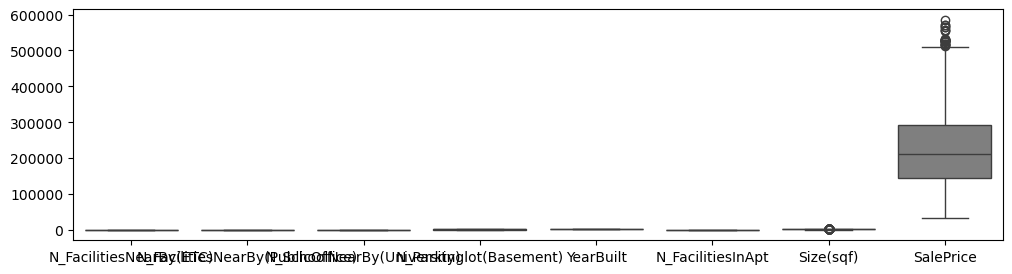

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,3))
sns.boxplot(
    data=df
)
plt.show()

Dari hasil data understanding, informasi yang didapatkan:
1. Dataset berisi informasi tentang data harga properti (apartemen) di Kota Daegu, Korea, dengan beberapa kriteria spesifikasi

2. Terdapat 10 kolom yang berisi informasi terkait spesifikasi/fasilitas apartemen, dan 1 kolom harga yang akan menjadi variabel target
    - HallwayType = Tipe apartemen
    - TimeToSubway = Waktu tempuh ke stasiun kereta terdekat dari apartemen
    - SubwayStation	= Nama stasiun kereta terdekat dari apartemen
    - N_FacilitiesNearBy(ETC) = Jumlah fasilitas umum di sekitar apartemen
    - N_FacilitiesNearBy(PublicOffice) = Jumlah kantor pemerintahan di sekitar apartemen
    - N_SchoolNearBy(University) = Jumlah kampus di sekitar apartemen
    - N_Parkinglot(Basement) = Jumlah tempat parkir di apartemen
    - YearBuilt = Tahun pembangunan apartemen
    - N_FacilitiesInApt = Jumlah fasilitas umum di apartemen
    - Size(sqf) = Ukuran apartemen
    - SalePrice	= Harga apartemen (WON)

3. Tidak terdapat data null pada semua kolom

4. Terdapat data outlier pada kolom ukuran apartemen dan harga apartemen

### Problem Statement

1. Stakeholders:
    - (Calon) User/Penyewa, memiliki problem untuk dapat menilai harga properti yang wajar sesuai dengan preferensi/kebutuhan
    - Developer/Pemilik/Agent, memiliki problem untuk dapat menentukan harga properti yang wajar sesuai dengan fasilitas/spesifikasi

2. Goals:
    - Tujuan utama dari model machine learning yang akan dibuat yaitu untuk dapat melakukan prediksi harga apartemen berdasarkan beberapa kriteria spesifikasi, dengan cara:
        - Menentukan model terbaik dari beberapa pilihan model dengan target performa model machine learning yang harus dicapai yakni memiliki `nilai persentase error (MAPE) < 20%`.
        - Menentukan fitur atau kriteria spesifikasi yang paling berpengaruh terhadap harga apartemen.
        - Memberikan rekomendasi terkait harga apartemen untuk user maupun pemilik properti.

## Data Cleaning

In [7]:
df_clean = df.copy()

### Outlier

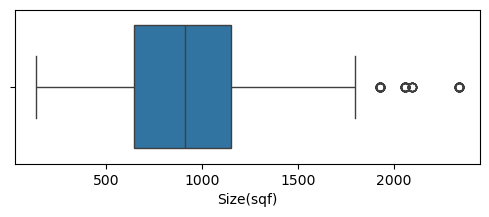

In [8]:
plt.figure(figsize=(6,2))
sns.boxplot(x=df_clean['Size(sqf)'])
plt.show()

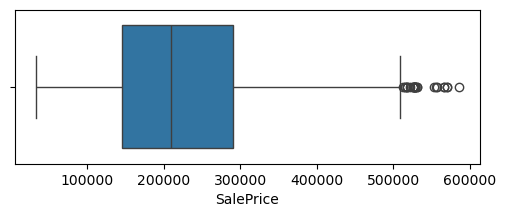

In [9]:
plt.figure(figsize=(6,2))
sns.boxplot(x=df_clean['SalePrice'])
plt.show()

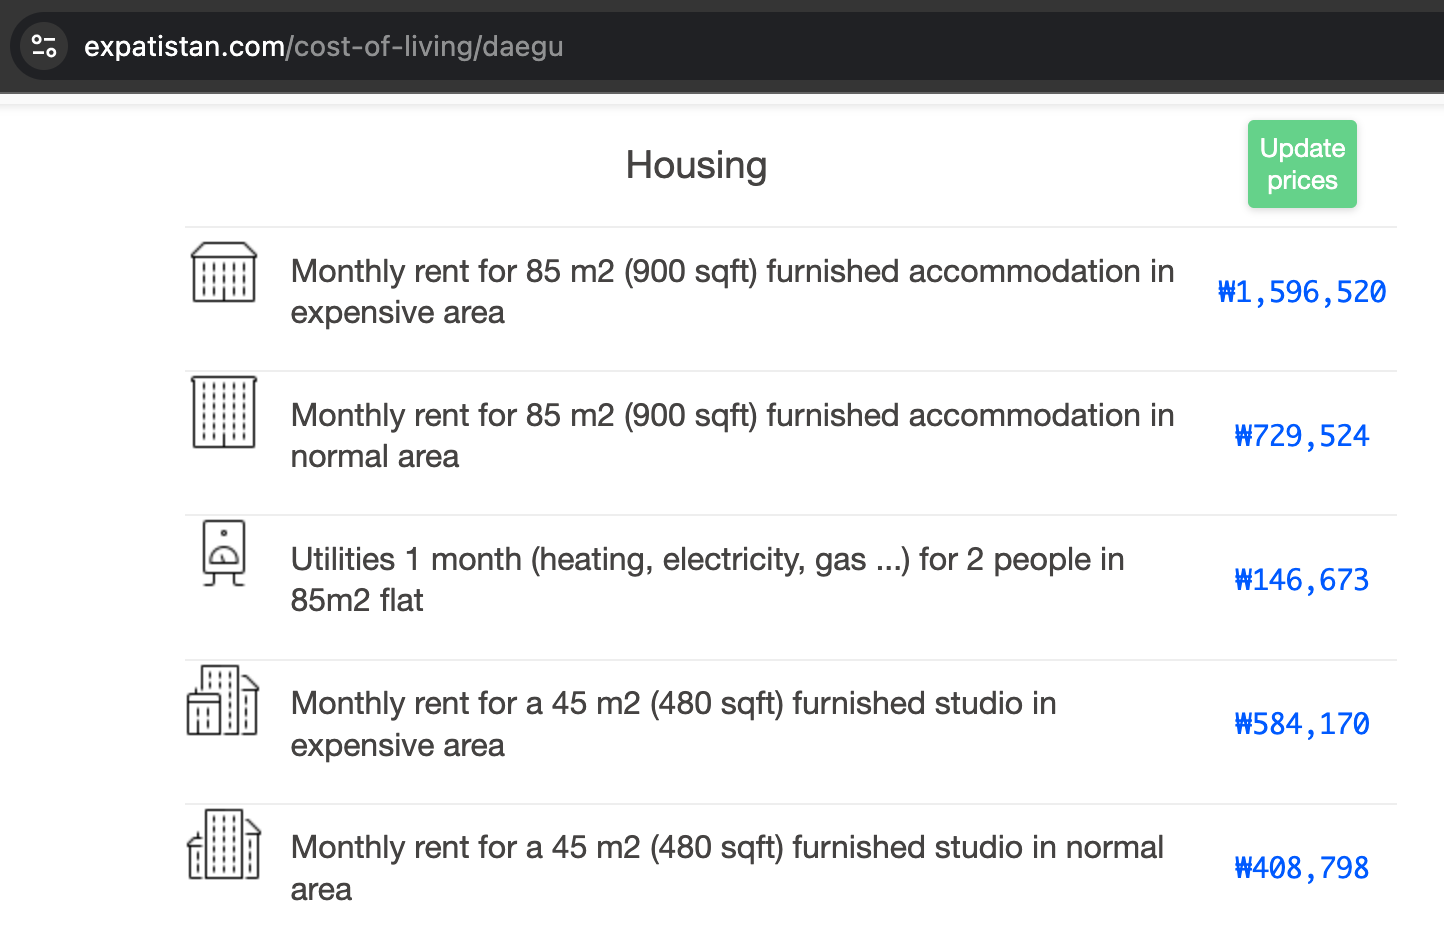

Referensi data berikut menunjukkan kisaran harga beserta ukuran dari apartemen yang ada di Daegu berdasarkan situs https://www.expatistan.com/cost-of-living/daegu. Dengan acuan data di atas, maka outlier pada fitur SalePrice dengan nilai maximum 585,480 WON dan Size(sqf) dengan nilai maximum 2,337 sqf masih dapat dikatakan valid dan masuk ke dalam rentang kisaran harga sesuai referensi sehingga dapat digunakan dalam proses pemodelan.

### Duplicate

In [10]:
df_clean = df_clean.drop_duplicates()

In [11]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2701 entries, 0 to 4121
Data columns (total 11 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   HallwayType                       2701 non-null   object 
 1   TimeToSubway                      2701 non-null   object 
 2   SubwayStation                     2701 non-null   object 
 3   N_FacilitiesNearBy(ETC)           2701 non-null   float64
 4   N_FacilitiesNearBy(PublicOffice)  2701 non-null   float64
 5   N_SchoolNearBy(University)        2701 non-null   float64
 6   N_Parkinglot(Basement)            2701 non-null   float64
 7   YearBuilt                         2701 non-null   int64  
 8   N_FacilitiesInApt                 2701 non-null   int64  
 9   Size(sqf)                         2701 non-null   int64  
 10  SalePrice                         2701 non-null   int64  
dtypes: float64(4), int64(4), object(3)
memory usage: 253.2+ KB


## Data Preprocessing

In [12]:
# Berdasarkan info df_clean di atas, index column 0-2 yang berupa object/kategori perlu dilakukan proses Encoding

import category_encoders as ce
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder

col_onehot = ['HallwayType','SubwayStation']
col_ordinal = ['TimeToSubway']

encod_onehot = OneHotEncoder(drop='first') # drop first untuk menghindari multikolinearitas pada model regresi yang sensitif
encod_ordinal = ce.OrdinalEncoder()
mapping_ordinal = [{
    'col':'TimeToSubway', 
    'mapping':{
        'no_bus_stop_nearby':0,
        '15min~20min':1,
        '10min~15min':2,
        '5min~10min':3, 
        '0-5min':4}
    }]

In [13]:
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer([
    ('onehot', encod_onehot, col_onehot),
    ('ordinal', encod_ordinal, col_ordinal)
], remainder='passthrough')

In [14]:
X = df_clean.drop(['SalePrice'], axis=1)
y = df_clean['SalePrice']

In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2042)

## Model

Berdasarkan karakteristik dataset, akan digunakan 2 metode yang paling cocok:
1. XGBoost
    - Sangat efektif untuk data dengan campuran fitur kategorikal dan numerik
    - Robust terhadap outlier dan multikolinearitas
    - Dapat menangani hubungan non-linear antara fitur dan target

2. Random Forest
    - Tidak memerlukan normalisasi data
    - Efektif untuk data campuran seperti ini
    - Robust terhadap outlier dan noise

In [16]:
from sklearn.preprocessing import RobustScaler
from sklearn.linear_model import Ridge
from xgboost.sklearn import XGBRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error

In [17]:
# Model pipelines
ridge_pipeline = Pipeline([
    ('preprocess', preprocessor),
    ('scaler', RobustScaler()),  # Penting untuk linear regression
    ('model', Ridge(random_state=2042))
])

xgb_pipeline = Pipeline([
    ('preprocess', preprocessor),
    ('model', XGBRegressor(random_state=2042))
])

rf_pipeline = Pipeline([
    ('preprocess', preprocessor),
    ('model', RandomForestRegressor(random_state=2042))
])

# Fit model
ridge_pipeline.fit(X_train, y_train)
xgb_pipeline.fit(X_train, y_train)
rf_pipeline.fit(X_train, y_train)

# Predict
y_pred_ridge = ridge_pipeline.predict(X_test)
y_pred_xgb = xgb_pipeline.predict(X_test)
y_pred_rf = rf_pipeline.predict(X_test)

# Evaluation Metrics
def evaluate_model(y_test, y_pred):
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mape = mean_absolute_percentage_error(y_test, y_pred) * 100
    return mae, rmse, mape

mae_ridge, rmse_ridge, mape_ridge = evaluate_model(y_test, y_pred_ridge)
mae_xgb, rmse_xgb, mape_xgb = evaluate_model(y_test, y_pred_xgb)
mae_rf, rmse_rf, mape_rf = evaluate_model(y_test, y_pred_rf)

results_1 = pd.DataFrame({
    'Model  ': ['XGBoost Raw  ', 'RandomForest Raw  ', 'Ridge Raw  '],
    'MAE': [mae_xgb, mae_rf, mae_ridge],
    'RMSE': [rmse_xgb, rmse_rf, rmse_ridge],
    'MAPE (%)': [mape_xgb, mape_rf, mape_ridge]
})

print(results_1)

              Model             MAE          RMSE   MAPE (%)
0       XGBoost Raw    38747.015625  47730.477978  19.696821
1  RandomForest Raw    38717.975101  47737.144563  19.692693
2         Ridge Raw    44113.378343  53529.889036  22.126642


Berdasarkan hasil Evaluation Metrics (MAPE) yang diperoleh masing-masing model, akan dipilih model XGBoost dan Random Forest untuk proses lanjutan karena memenuhi kriteria MAPE < 20%.

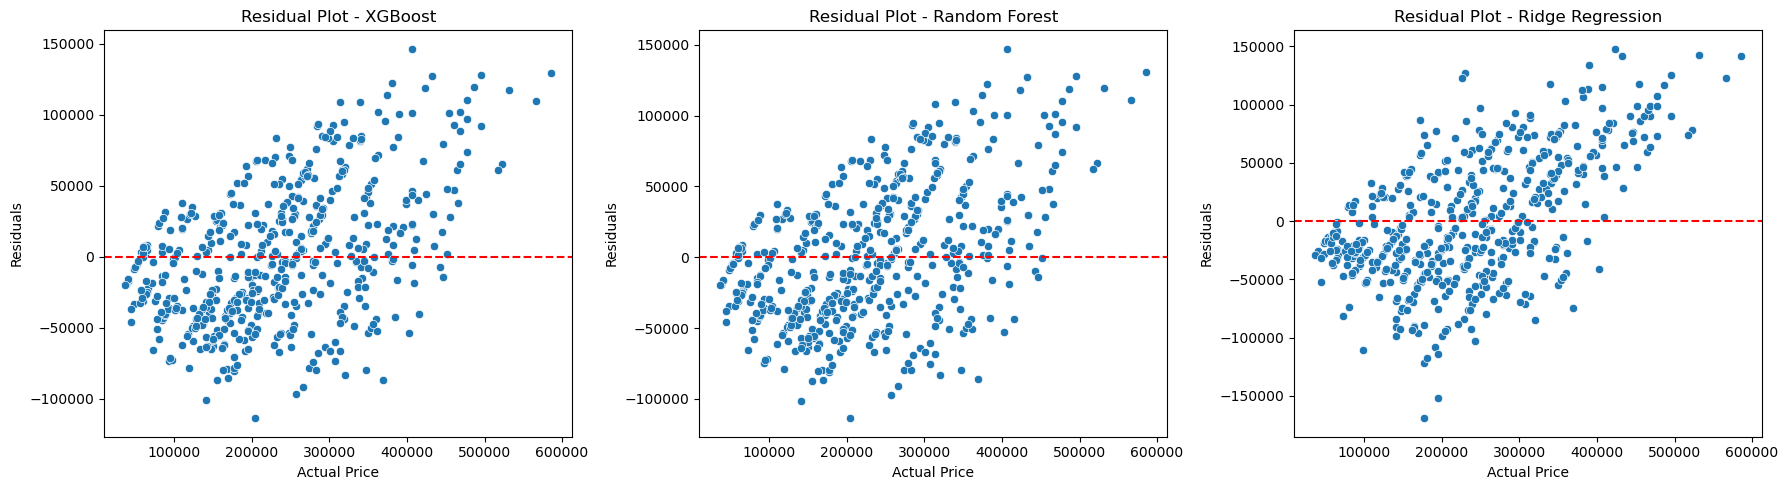

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

# Hitung residuals
residuals_xgb = y_test - y_pred_xgb
residuals_rf = y_test - y_pred_rf
residuals_ridge = y_test - y_pred_ridge

# Plot residuals
plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
sns.scatterplot(x=y_test, y=residuals_xgb)
plt.axhline(0, color='red', linestyle='--')
plt.title('Residual Plot - XGBoost')
plt.xlabel('Actual Price')
plt.ylabel('Residuals')

plt.subplot(1, 3, 2)
sns.scatterplot(x=y_test, y=residuals_rf)
plt.axhline(0, color='red', linestyle='--')
plt.title('Residual Plot - Random Forest')
plt.xlabel('Actual Price')
plt.ylabel('Residuals')

plt.subplot(1, 3, 3)
sns.scatterplot(x=y_test, y=residuals_ridge)
plt.axhline(0, color='red', linestyle='--')
plt.title('Residual Plot - Ridge Regression')
plt.xlabel('Actual Price')
plt.ylabel('Residuals')

plt.tight_layout()
plt.show()

Kesimpulan Residual Plot:

| Model            | Penyebaran Residual                                    | Pola Error                   | Indikasi                               |
| ---------------- | ------------------------------------------------------ | ---------------------------- | -------------------------------------- |
| XGBoost          | Relatif merata, spread sedikit melebar di harga tinggi | Tidak ada pola sistematis    | Baik, ada heteroskedastisitas ringan   |
| Random Forest    | Relatif merata, spread melebar di harga tinggi         | Tidak ada pola sistematis    | Baik, sedikit kesulitan di harga mahal |
| Ridge Regression | Spread residual lebih besar                            | Underpredict di harga tinggi | Kurang baik, kemungkinan underfit      |


## Tuning

### Hyperparameter Tuning XGB

In [19]:
from sklearn.model_selection import RandomizedSearchCV, KFold

# Setup K-Fold Cross Validation
kfold = KFold(n_splits=5, shuffle=True, random_state=2042)

# Parameter grid untuk XGBoost
param_dist_xgb = {
    'model__n_estimators': [100, 200, 300, 400],
    'model__max_depth': [3, 4, 5, 6, 7],
    'model__learning_rate': [0.01, 0.05, 0.1, 0.2],
    'model__subsample': [0.6, 0.8, 1.0],
    'model__colsample_bytree': [0.6, 0.8, 1.0]
}

random_search_xgb = RandomizedSearchCV(
    estimator=xgb_pipeline,
    param_distributions=param_dist_xgb,
    n_iter=20,
    cv=kfold,
    scoring='neg_mean_absolute_error',
    n_jobs=-1,
    random_state=2042,
    verbose=1
)

random_search_xgb.fit(X_train, y_train)


Fitting 5 folds for each of 20 candidates, totalling 100 fits


/Applications/anaconda3/lib/python3.12/site-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


RandomizedSearchCV(cv=KFold(n_splits=5, random_state=2042, shuffle=True),
                   estimator=Pipeline(steps=[('preprocess',
                                              ColumnTransformer(remainder='passthrough',
                                                                transformers=[('onehot',
                                                                               OneHotEncoder(drop='first'),
                                                                               ['HallwayType',
                                                                                'SubwayStation']),
                                                                              ('ordinal',
                                                                               OrdinalEncoder(),
                                                                               ['TimeToSubway'])])),
                                             ('model',
                                              XGBRegressor(base_score=None,
                                                           booster=None,
                                                           callbacks=No...
                                                           n_estimators=None,
                                                           n_jobs=None,
                                                           num_parallel_tree=None, ...))]),
                   n_iter=20, n_jobs=-1,
                   param_distributions={'model__colsample_bytree': [0.6, 0.8,
                                                                    1.0],
                                        'model__learning_rate': [0.01, 0.05,
                                                                 0.1, 0.2],
                                        'model__max_depth': [3, 4, 5, 6, 7],
                                        'model__n_estimators': [100, 200, 300,
                                                                400],
                                        'model__subsample': [0.6, 0.8, 1.0]},
                   random_state=2042, scoring='neg_mean_absolute_error',
                   verbose=1)

### Hyperparameter Tuning Random Forest

In [20]:
# Parameter grid untuk Random Forest
param_dist_rf = {
    'model__n_estimators': [100, 200, 300, 400],
    'model__max_depth': [None, 5, 10, 15],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf': [1, 2, 4],
    'model__max_features': ['auto', 'sqrt', 'log2']
}

random_search_rf = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=param_dist_rf,
    n_iter=20,
    cv=kfold,
    scoring='neg_mean_absolute_error',
    n_jobs=-1,
    random_state=2042,
    verbose=1
)

random_search_rf.fit(X_train, y_train)


Fitting 5 folds for each of 20 candidates, totalling 100 fits


/Applications/anaconda3/lib/python3.12/site-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
20 fits failed out of a total of 100.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
10 fits failed with the following error:
Traceback (most recent call last):
  File "/Applications/anaconda3/lib/python3.12/site-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/Applications/anaconda3/lib/python3.12/site-packages/sklearn/base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Applications/anaconda3/lib/python3.12/site-packages/sklearn/pipeline.py", line 

RandomizedSearchCV(cv=KFold(n_splits=5, random_state=2042, shuffle=True),
                   estimator=Pipeline(steps=[('preprocess',
                                              ColumnTransformer(remainder='passthrough',
                                                                transformers=[('onehot',
                                                                               OneHotEncoder(drop='first'),
                                                                               ['HallwayType',
                                                                                'SubwayStation']),
                                                                              ('ordinal',
                                                                               OrdinalEncoder(),
                                                                               ['TimeToSubway'])])),
                                             ('model',
                                              RandomForestRegressor(random_state=2042))]),
                   n_iter=20, n_jobs=-1,
                   param_distributions={'model__max_depth': [None, 5, 10, 15],
                                        'model__max_features': ['auto', 'sqrt',
                                                                'log2'],
                                        'model__min_samples_leaf': [1, 2, 4],
                                        'model__min_samples_split': [2, 5, 10],
                                        'model__n_estimators': [100, 200, 300,
                                                                400]},
                   random_state=2042, scoring='neg_mean_absolute_error',
                   verbose=1)

In [21]:
# Best Model Prediction
best_xgb = random_search_xgb.best_estimator_
best_rf = random_search_rf.best_estimator_

y_pred_xgb_tuned = best_xgb.predict(X_test)
y_pred_rf_tuned = best_rf.predict(X_test)

# Evaluation
mae_xgb_tuned, rmse_xgb_tuned, mape_xgb_tuned = evaluate_model(y_test, y_pred_xgb_tuned)
mae_rf_tuned, rmse_rf_tuned, mape_rf_tuned = evaluate_model(y_test, y_pred_rf_tuned)

results_2 = pd.DataFrame({
    'Model': ['XGBoost Tuned', 'RandomForest Tuned'],
    'MAE': [mae_xgb_tuned, mae_rf_tuned],
    'RMSE': [rmse_xgb_tuned, rmse_rf_tuned],
    'MAPE (%)': [mape_xgb_tuned, mape_rf_tuned]
})

print(results_2)

                Model           MAE          RMSE   MAPE (%)
0       XGBoost Tuned  38494.144531  47431.122272  19.557415
1  RandomForest Tuned  38696.535453  47692.762407  19.676549


### Transform Target

In [22]:
# Transformasi target menggunakan log1p (log(1+x)) untuk menghindari log(0)
y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)

### Feature Engineering

In [23]:
X_train_fe = X_train.copy()
X_test_fe = X_test.copy()

# Fitur interaksi: Ukuran apartemen * Jumlah fasilitas di apartemen
X_train_fe['Size_Facilities'] = X_train_fe['Size(sqf)'] * X_train_fe['N_FacilitiesInApt']
X_test_fe['Size_Facilities'] = X_test_fe['Size(sqf)'] * X_test_fe['N_FacilitiesInApt']

# Fitur rasio: Jumlah parkir per ukuran apartemen
X_train_fe['Parking_per_Size'] = X_train_fe['N_Parkinglot(Basement)'] / X_train_fe['Size(sqf)']
X_test_fe['Parking_per_Size'] = X_test_fe['N_Parkinglot(Basement)'] / X_test_fe['Size(sqf)']

In [24]:
# Training with Target Log
best_xgb.fit(X_train_fe, y_train_log)
best_rf.fit(X_train_fe, y_train_log)

# Predict
y_pred_xgb_log = np.expm1(best_xgb.predict(X_test_fe))
y_pred_rf_log = np.expm1(best_rf.predict(X_test_fe))

# Evaluation
# Evaluasi hasil
mae_xgb_log, rmse_xgb_log, mape_xgb_log = evaluate_model(y_test, y_pred_xgb_log)
mae_rf_log, rmse_rf_log, mape_rf_log = evaluate_model(y_test, y_pred_rf_log)

results_3 = pd.DataFrame({
    'Model   ': ['XGB Tuned Final   ', 'RF Tuned Final   '],
    'MAE': [mae_xgb_log, mae_rf_log],
    'RMSE': [rmse_xgb_log, rmse_rf_log],
    'MAPE (%)': [mape_xgb_log, mape_rf_log]
})

print(results_3)


             Model              MAE          RMSE   MAPE (%)
0  XGB Tuned Final     38158.378906  47661.421884  18.861939
1   RF Tuned Final     38422.064395  47901.764022  18.970392


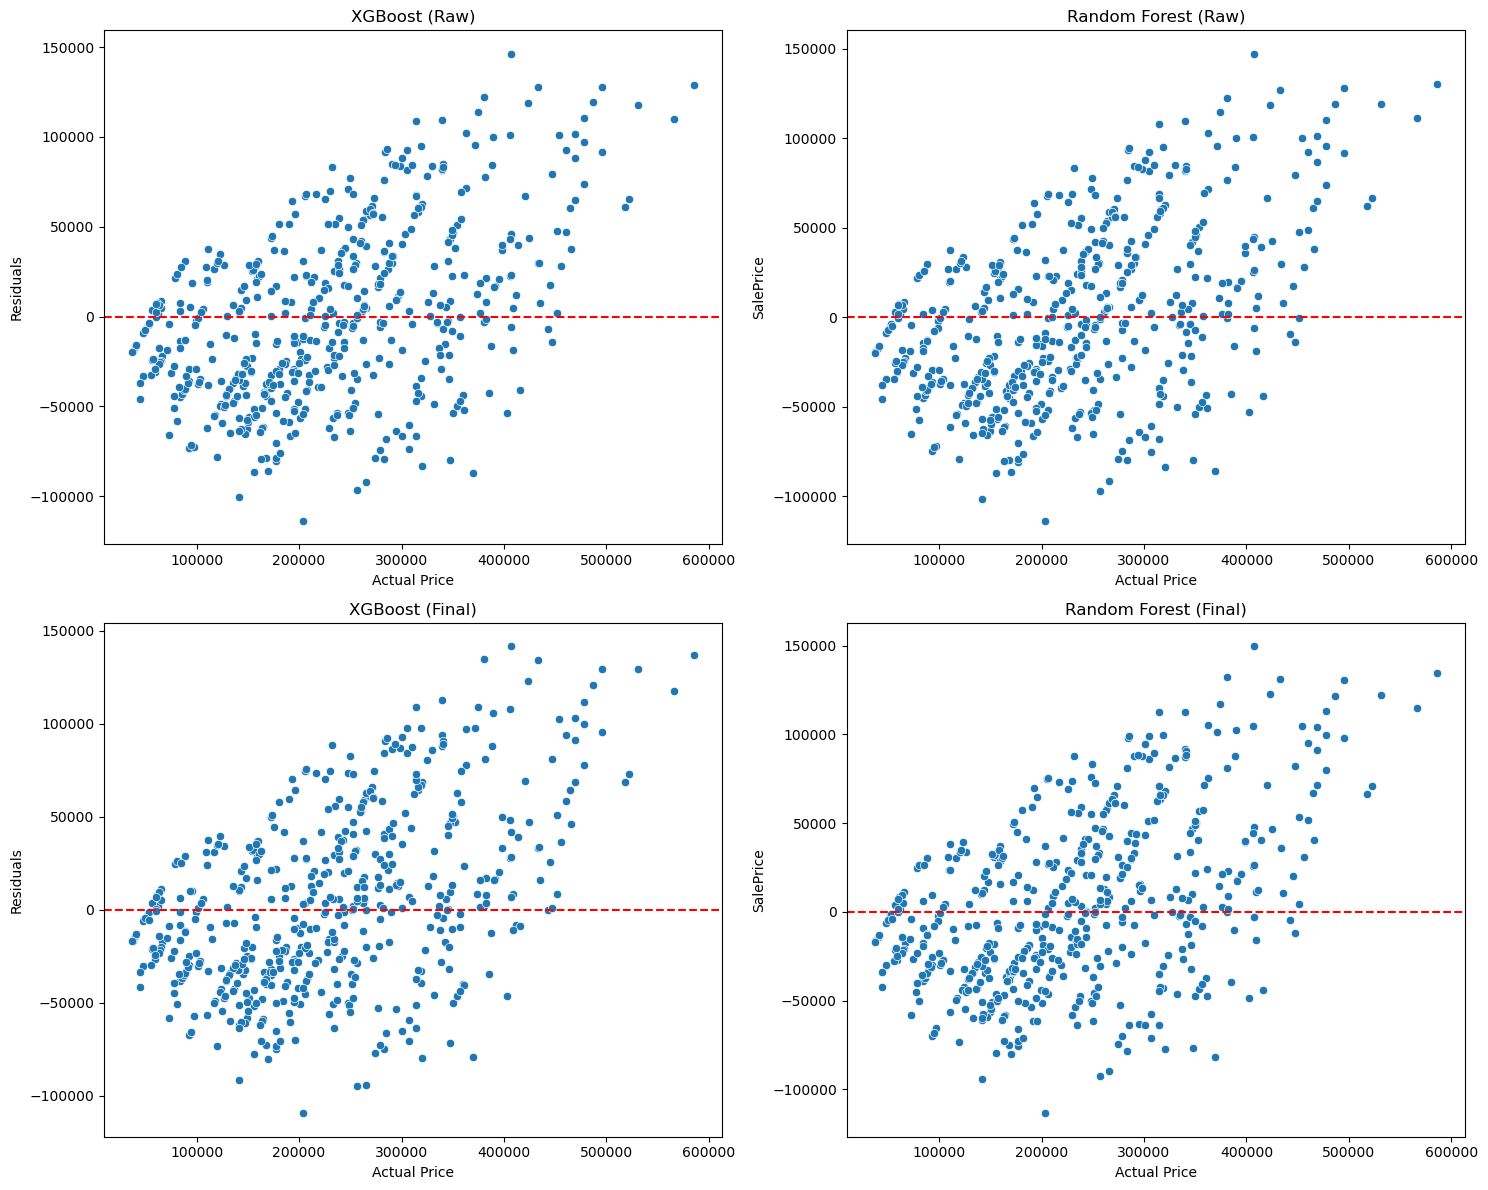

In [25]:
plt.figure(figsize=(15, 12))

# Hitung residual untuk model akhir
residuals_xgb_log = y_test - y_pred_xgb_log
residuals_rf_log = y_test - y_pred_rf_log

# XGBoost Sebelum Transformasi
plt.subplot(2, 2, 1)
sns.scatterplot(x=y_test, y=residuals_xgb)
plt.axhline(0, color='red', linestyle='--')
plt.title('XGBoost (Raw)')
plt.xlabel('Actual Price')
plt.ylabel('Residuals')

# Random Forest Sebelum Transformasi
plt.subplot(2, 2, 2)
sns.scatterplot(x=y_test, y=residuals_rf)
plt.axhline(0, color='red', linestyle='--')
plt.title('Random Forest (Raw)')
plt.xlabel('Actual Price')

# XGBoost Setelah Transformasi Log + Feature Engineering
plt.subplot(2, 2, 3)
sns.scatterplot(x=y_test, y=residuals_xgb_log)
plt.axhline(0, color='red', linestyle='--')
plt.title('XGBoost (Final)')
plt.xlabel('Actual Price')
plt.ylabel('Residuals')

# Random Forest Setelah Transformasi Log + Feature Engineering
plt.subplot(2, 2, 4)
sns.scatterplot(x=y_test, y=residuals_rf_log)
plt.axhline(0, color='red', linestyle='--')
plt.title('Random Forest (Final)')
plt.xlabel('Actual Price')

plt.tight_layout()
plt.show()


| Model                                    | MAE (WON) | RMSE (WON) | MAPE (%) |
| ---------------------------------------- | --------- | ---------- | -------- |
| XGBoost Raw                     | 38747.015625       | 47730.477978         | 19.696821       |
| Random Forest Raw               | 38717.975101       | 47737.144563         | 19.692693       |
| XGBoost Tuned       | 38494.144531        | 47431.122272         | 19.557415       |    
| Random Forest Tuned | 38696.535453        | 47692.762407         | 19.676549       |    
| XGBoost Tuned Final      | 38158.378906       | 47661.421884         | `18.861939`       |    
| Random Forest Tuned Final | 38422.064395        | 47901.764022         | 18.970392       |


Berdasarkan tabel perbandingan evaluation metrics antara algoritma XGBoost dan Random Forest, dapat disimpulkan bahwa model terbaik adalah `XGBoost` berdasarkan nilai persentase MAPE yang diperoleh.

## Interpretation

### Actual vs Prediction

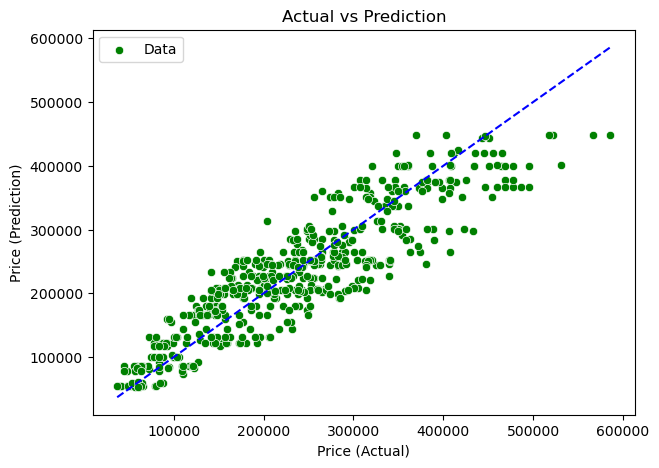

In [26]:
plt.figure(figsize=(7, 5)) 
sns.scatterplot(x=y_test, y=y_pred_xgb_log, label='Data', marker='o', color='green')
plt.xlabel('Price (Actual)')  
plt.ylabel('Price (Prediction)')    
plt.title('Actual vs Prediction')
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], linestyle='--', color='blue')
plt.show() 

Hasil analisis nilai Actual vs Prediction menggunakan Scatter Plot:

1. Sebagian besar titik sudah cukup dekat dengan garis diagonal, berarti model sudah cukup baik dalam memprediksi harga apartemen.

2. Terdapat penyebaran (variansi) yang agak besar, terutama pada harga apartemen yang lebih tinggi (di atas 300.000 WON). Artinya, model cenderung kurang akurat dalam memprediksi harga properti yang mahal. Hal tersebut bisa terjadi karena data properti dengan harga mahal pada dataset jumlahnya lebih sedikit, sehingga model belajar lebih baik pada range harga middle-low.

3. Pola penyebaran di atas dan di bawah garis cukup simetris, menandakan model tidak bias secara sistematis (tidak selalu overestimate atau underestimate).

4. Potensi Perbaikan

    Performa sudah cukup baik, tapi untuk properti high-end, model mungkin butuh tambahan data atau fitur yang lebih spesifik, seperti:
    - Developer properti (popularitas)
    - View apartemen
    - Fasilitas mewah

### Feature Importance

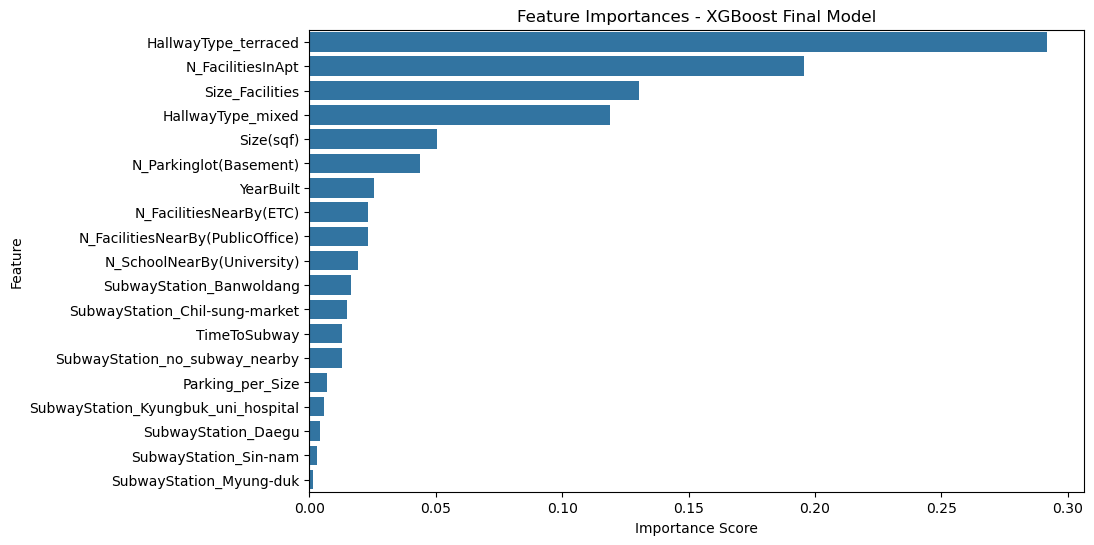

                                Feature  Importance
1                  HallwayType_terraced    0.292017
15                    N_FacilitiesInApt    0.195692
17                      Size_Facilities    0.130416
0                     HallwayType_mixed    0.118792
16                            Size(sqf)    0.050294
13               N_Parkinglot(Basement)    0.043656
14                            YearBuilt    0.025500
10              N_FacilitiesNearBy(ETC)    0.023125
11     N_FacilitiesNearBy(PublicOffice)    0.023047
12           N_SchoolNearBy(University)    0.019130
2              SubwayStation_Banwoldang    0.016267
3        SubwayStation_Chil-sung-market    0.014831
9                          TimeToSubway    0.013044
8        SubwayStation_no_subway_nearby    0.012815
18                     Parking_per_Size    0.006977
5   SubwayStation_Kyungbuk_uni_hospital    0.005861
4                   SubwayStation_Daegu    0.004120
7                 SubwayStation_Sin-nam    0.002926
6           

In [27]:
# Ambil nama fitur setelah preprocessing
# Get feature names from the one-hot encoder
onehot_features = list(best_xgb.named_steps['preprocess'].transformers_[0][1].get_feature_names_out(col_onehot))
ordinal_features = col_ordinal
other_features = [col for col in X_train_fe.columns if col not in col_onehot + col_ordinal]

# Gabungkan semua nama fitur (urutan harus sesuai dengan urutan input ke model)
final_features = onehot_features + ordinal_features + other_features

# Ambil feature importances
importances = best_xgb.named_steps['model'].feature_importances_
feature_importance_df = pd.DataFrame({'Feature': final_features, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Plot feature importances
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df)
plt.title('Feature Importances - XGBoost Final Model')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.show()

# Tampilkan tabel feature importance
print(feature_importance_df)

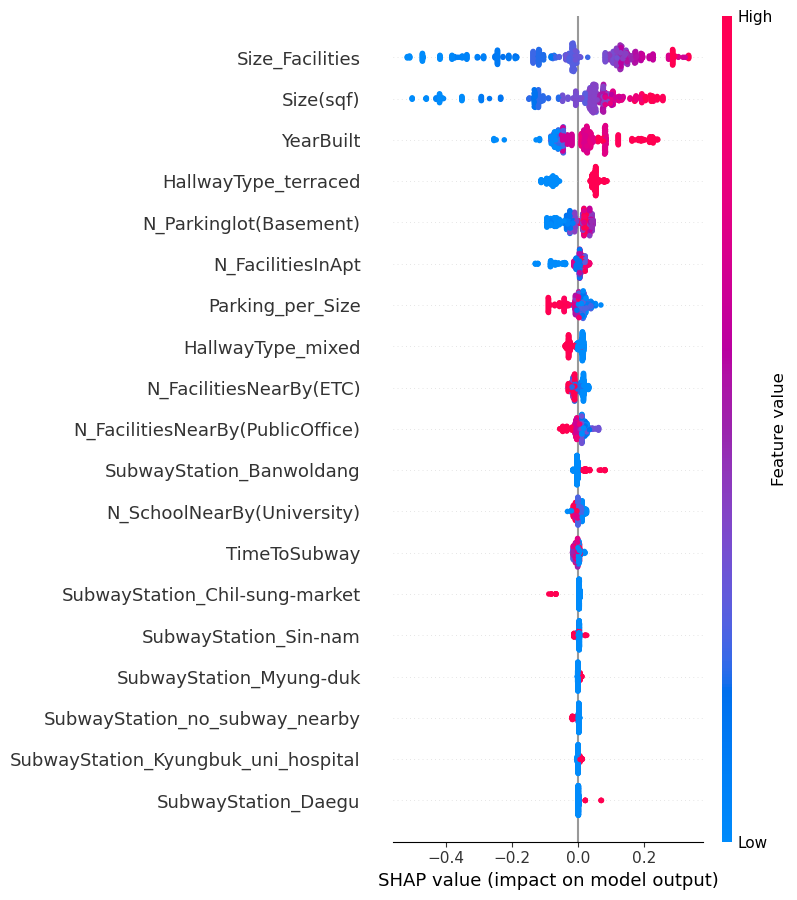

In [28]:
import shap

# Inisialisasi explainer untuk XGBoost
explainer = shap.Explainer(best_xgb.named_steps['model'])

# Ambil data yang sudah dipreprocess (fitur akhir)
X_test_preprocessed = best_xgb.named_steps['preprocess'].transform(X_test_fe)

# Hitung SHAP values
shap_values = explainer(X_test_preprocessed)

# Ambil nama fitur yang sudah digabung sebelumnya
final_features = onehot_features + ordinal_features + other_features

# Summary Plot
plt.figure(figsize=(10, 7))
shap.summary_plot(shap_values, features=X_test_preprocessed, feature_names=final_features)


Hasil analisis feature importances menggunakan SHAP:

1. Fitur Paling Berpengaruh
Size_Facilities dan Size(sqf) adalah dua fitur yang paling berpengaruh besar terhadap model. Ini artinya ukuran apartemen dan interaksinya dengan jumlah fasilitas di dalam apartemen adalah faktor penentu utama dalam model prediksi harga apartemen.

2. Fitur yang Kurang Signifikan
Beberapa stasiun subway seperti SubwayStation_Daegu, SubwayStation_Kyungbuk_uni_hospital, dan SubwayStation_no_subway_nearby memiliki kontribusi yang kecil dan dekat dengan nol (mungkin tidak terlalu mempengaruhi model).

3. Distribusi Residual Masih Variatif
Walaupun sudah dilakukan feature engineering, terlihat bahwa sebagian besar fitur memiliki variasi SHAP value yang cukup terpusat di sekitar nol, artinya model cukup stabil. Namun, ada beberapa fitur yang masih memiliki outliers, ini menandakan beberapa prediksi individual mungkin masih kurang akurat (bisa jadi pada data outlier yang sulit diprediksi dengan sempurna).

SHAP Feature Importance Summary Table

| No | Fitur                             | Pengaruh Terhadap Harga | Interpretasi Singkat                                            |
| -- | --------------------------------- | ----------------------- | --------------------------------------------------------------- |
| 1  | Size\_Facilities                  | Tinggi                  | Apartemen besar dengan banyak fasilitas → harga cenderung naik. |
| 2  | Size(sqf)                         | Tinggi                  | Semakin besar ukuran apartemen → semakin tinggi harga.          |
| 3  | YearBuilt                         | Sedang                  | Apartemen baru → cenderung meningkatkan harga.                  |
| 4  | HallwayType\_terraced             | Sedang                  | Tipe hallway terraced → mendorong harga naik.                   |
| 5  | N\_Parkinglot(Basement)           | Sedang                  | Semakin banyak parkir → harga apartemen lebih tinggi.           |
| 6  | N\_FacilitiesInApt                | Sedang                  | Semakin banyak fasilitas di apartemen → harga cenderung naik.   |
| 7  | Parking\_per\_Size                | Sedang                  | Rasio parkir per ukuran → pengaruh positif sedang.              |
| 8  | HallwayType\_mixed                | Rendah                  | Tipe hallway mixed → pengaruh kecil ke harga.                   |
| 9  | N\_FacilitiesNearBy(ETC)          | Rendah                  | Fasilitas umum sekitar → pengaruh kecil ke harga.               |
| 10 | N\_FacilitiesNearBy(PublicOffice) | Rendah                  | Kantor publik sekitar → pengaruh kecil ke harga.                |
| 11 | SubwayStation\_Banwoldang         | Rendah                  | Lokasi dekat stasiun ini → sedikit meningkatkan harga.          |
| 12 | N\_SchoolNearBy(University)       | Rendah                  | Kampus terdekat → pengaruh kecil ke harga.                      |
| 13 | TimeToSubway                      | Rendah                  | Semakin dekat ke stasiun → pengaruh kecil pada harga.           |
| 14 | SubwayStation\_Others             | Sangat Rendah           | Pengaruh lokasi selain Banwoldang hampir tidak signifikan.      |


Alasan pemilihan metode SHAP

| Aspek                 | (XGBoost .feature_importances_)                                                                         | SHAP (Shapley Additive Explanations)                                                      |
| --------------------- | ---------------------------------------------------------------------------------------------------------------------------------- | ----------------------------------------------------------------------------------------- |
| **Metode Pengukuran** | Berdasarkan **berapa sering** dan **seberapa penting** sebuah fitur dipakai dalam split decision tree.                             | Berdasarkan **kontribusi setiap fitur** terhadap setiap prediksi individu.                |
| **Level Analisis**    | Global (rata-rata pentingnya fitur di seluruh model).                                                                              | Lokal dan Global (pengaruh fitur pada masing-masing prediksi dan secara keseluruhan).     |
| **Tipe Interpretasi** | Memberikan gambaran kasar: fitur mana yang paling sering digunakan.                                                                | Memberikan interpretasi yang detail dan adil (berbasis teori game).                       |
| **Kelebihan**         | Cepat, sederhana.                                                                                                                  | Akurat, mempertimbangkan interaksi antar fitur, lebih informatif.                         |
| **Kelemahan**         | Tidak mempertimbangkan interaksi fitur. Rentan bias jika ada fitur saling berkorelasi.                                             | Komputasi lebih berat, tapi hasil jauh lebih terpercaya.                                  |
| **Contoh Bias**       | Fitur yang sering muncul dalam pohon (misalnya karena split awal) bisa terlihat penting, padahal tidak terlalu mempengaruhi hasil. | SHAP membagi kontribusi fitur secara proporsional dan adil, jadi hasilnya lebih objektif. |


### High Price Residual

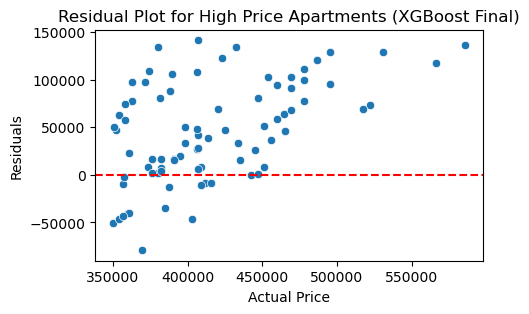

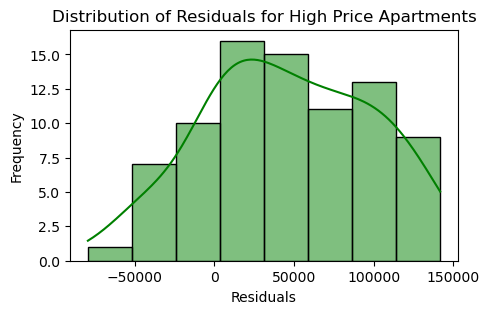

In [29]:
# Tentukan threshold
high_price_threshold = 350000

# Filter data dengan harga tinggi
high_price_mask = y_test > high_price_threshold
y_test_high = y_test[high_price_mask]
y_pred_high = y_pred_xgb_log[high_price_mask]

# Hitung residual
residuals_high = y_test_high - y_pred_high

# Plot residuals untuk harga tinggi
plt.figure(figsize=(5, 3))
sns.scatterplot(x=y_test_high, y=residuals_high)
plt.axhline(0, color='red', linestyle='--')
plt.title('Residual Plot for High Price Apartments (XGBoost Final)')
plt.xlabel('Actual Price')
plt.ylabel('Residuals')
plt.show()

# Tambahan: Histogram error untuk high price
plt.figure(figsize=(5, 3))
sns.histplot(residuals_high, kde=True, color='green')
plt.title('Distribution of Residuals for High Price Apartments')
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.show()

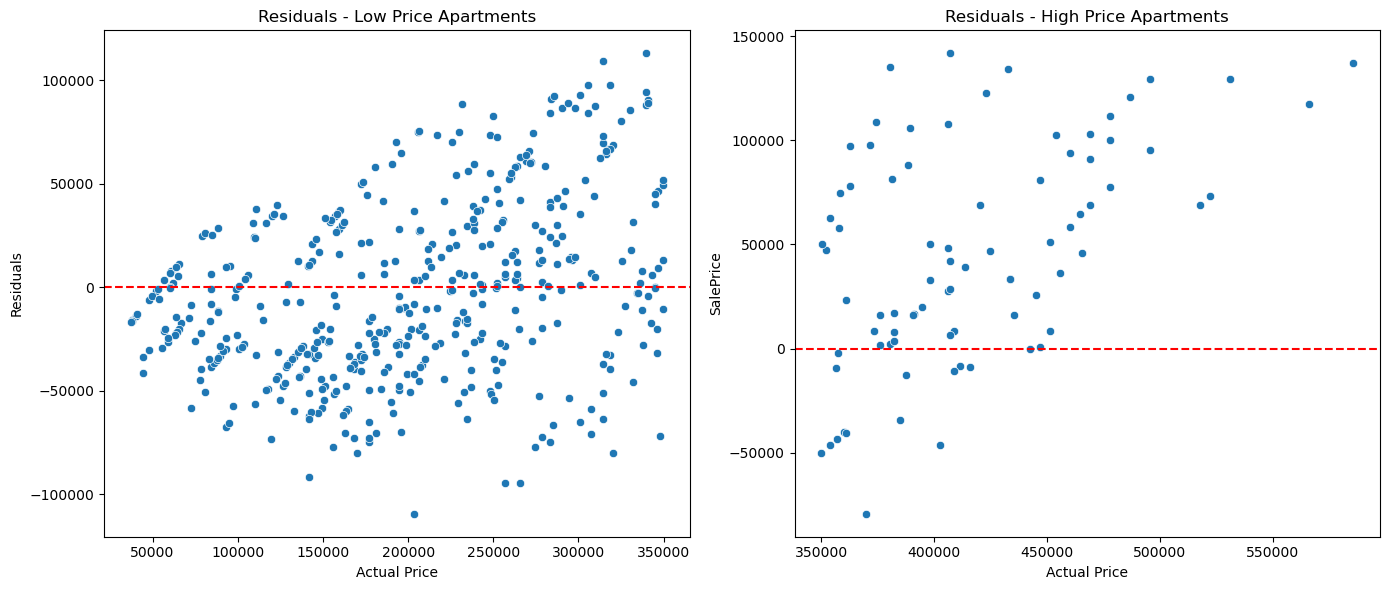

In [30]:
# Low price subset
low_price_mask = y_test <= high_price_threshold
y_test_low = y_test[low_price_mask]
y_pred_low = y_pred_xgb_log[low_price_mask]
residuals_low = y_test_low - y_pred_low

# Plot side by side
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.scatterplot(x=y_test_low, y=residuals_low)
plt.axhline(0, color='red', linestyle='--')
plt.title('Residuals - Low Price Apartments')
plt.xlabel('Actual Price')
plt.ylabel('Residuals')

plt.subplot(1, 2, 2)
sns.scatterplot(x=y_test_high, y=residuals_high)
plt.axhline(0, color='red', linestyle='--')
plt.title('Residuals - High Price Apartments')
plt.xlabel('Actual Price')

plt.tight_layout()
plt.show()

Hasil analisis Residual untuk High Price:

1. Residual Plot
    - Sebaran residual menunjukkan sebagian besar prediksi untuk apartemen dengan harga tinggi cenderung underestimate. Artinya, model sering memprediksi harga lebih rendah dibandingkan harga aktual untuk segmen ini.
    - Terdapat beberapa titik yang residualnya negatif, artinya model sesekali juga overestimate, nammun frekuensinya lebih sedikit.
    - Sebaran residual tidak sepenuhnya random, terlihat ada pola residual yang membesar seiring dengan kenaikan harga aktual. Ini indikasi adanya heteroskedastisitas (varian error membesar pada harga tinggi).
    - Model cenderung kurang akurat dan memiliki bias sistematis di segmen ini.

2. Histogram
    - Histogram menunjukkan distribusi residual untuk apartemen harga tinggi cenderung condong ke kanan (positif).
    - Titik rata-rata sedikit berada di sisi positif, memperkuat bahwa model lebih sering memprediksi harga di bawah nilai sebenarnya.
    - Distribusi residual cukup lebar, artinya error prediksi di segmen ini cukup besar.
    - Kemungkinan terjadi underfitting, atau terdapat fitur penting yang belum mampu dijelaskan model secara optimal untuk segmen ini.

## Kesimpulan

1. Model terbaik yaitu XGBoost setelah melalui proses Tuning dan Feature Engineering.

2. Model paling mengandalkan fitur/kriteria Ukuran Apartemen dan Jumlah Fasilitas sebagai prediktor utama.

3. Model dapat dikategorikan layak dengan tingkat persentase error di bawah 20%, yakni sebesar 18.86%, dimana hasil prediksi yang dihasilkan cukup akurat dengan nilai error yang masih dapat ditoleransi.

4. Limitasi model: Model cenderung mendapatkan akurasi yang tinggi pada data dengan spesifikasi umum (mainstream), namun memiliki potensi kurang akurat pada apartemen dengan spesifikasi yang tidak umum (outlier), dalam hal ini model kurang akurat untuk memprediksi harga apartemen yang tinggi (> 300,000 WON).

4. Rekomendasi Bisnis:

    a. Gunakan Model Ini Sebagai Pricing Guidance Tool:
    - Model dapat membantu user untuk menilai kewajaran harga jual suatu apartemen, sehingga dapat digunakan untuk mendeteksi harga yang terlalu tinggi atau terlalu rendah dari harga pasar.
    - Bagi Developer/Agen/Pemilik properti, perlu mempertimbangkan perluasan fasilitas tempat parkir dan penambahan fasilitas di dalam apartemen untuk dapat meningkatkan harga jual untuk properti yang sudah dibangun. Namun, apabila properti baru akan dibangun, tentu faktor luas atau ukuran apartemen menjadi faktor utama yang perlu dipenuhi sehingga harga jual semakin tinggi.

    b. Future Development:
    - Model bisa terus diperbarui dengan data harga terbaru, terutama diperlukan penambahan untuk segmentasi harga yang mahal karena hasil prediksinya masih kurang akurat. Bisa juga dengan menambahkan fitur lain seperti Developer Apartemen (Popularitas), View Apartemen, dan Fasilitas Mewah untuk hasil yang lebih akurat pada segmen harga mahal.

In [31]:
# Menyimpan model ke dalam file .sav

import pickle

filename = 'XGB_apartment_price_predictor.sav'
pickle.dump(best_xgb, open(filename, 'wb'))